In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib, os

df = pd.read_csv('../data/clean_matches.csv')
df['played_at'] = pd.to_datetime(df['played_at'], errors='coerce')
df = df.dropna(subset=['played_at'])

# Agrégation mensuelle du nombre de matchs
ts = df.groupby(df['played_at'].dt.to_period('M')).size()
ts.index = ts.index.to_timestamp()
ts = ts.sort_index()

print("Période:", ts.index[0], "→", ts.index[-1])
print("Nombre de mois:", len(ts))
print(ts)

Période: 2025-09-01 00:00:00 → 2025-12-01 00:00:00
Nombre de mois: 4
played_at
2025-09-01    411
2025-10-01    278
2025-11-01    557
2025-12-01     14
Freq: MS, dtype: int64


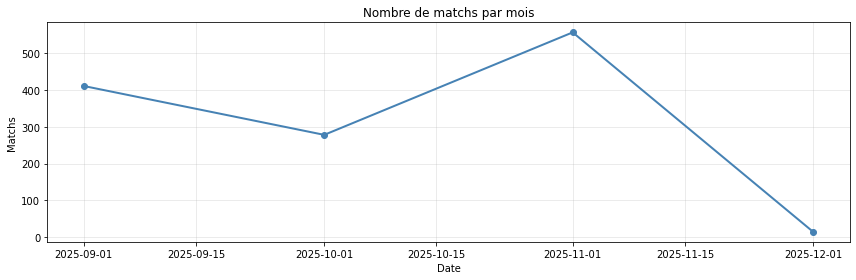

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts.values, marker='o', linewidth=2, color='steelblue')
plt.title('Nombre de matchs par mois')
plt.xlabel('Date'); plt.ylabel('Matchs')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ARIMA — MAE: 360.14 | RMSE: 360.14


C:\Users\hammo\anaconda33\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


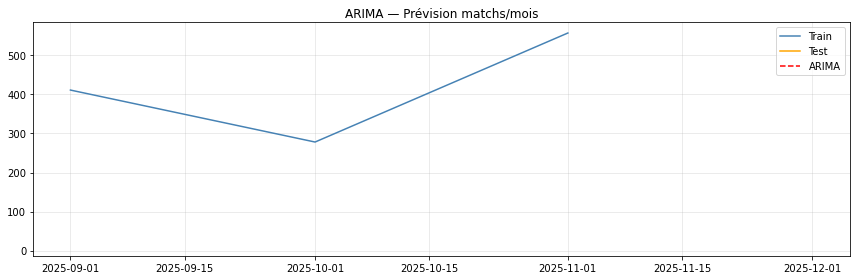

In [3]:
# Split train/test (80/20)
split = int(len(ts) * 0.8)
train, test = ts[:split], ts[split:]

arima = ARIMA(train, order=(1,1,1))
arima_fit = arima.fit()

preds_arima = arima_fit.forecast(steps=len(test))
mae_arima  = mean_absolute_error(test, preds_arima)
rmse_arima = mean_squared_error(test, preds_arima) ** 0.5

print(f"ARIMA — MAE: {mae_arima:.2f} | RMSE: {rmse_arima:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Train', color='steelblue')
plt.plot(test.index,  test.values,  label='Test',  color='orange')
plt.plot(test.index,  preds_arima,  label='ARIMA', color='red', linestyle='--')
plt.title('ARIMA — Prévision matchs/mois')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

00:28:25 - cmdstanpy - INFO - Chain [1] start processing
00:28:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 548.68 | RMSE: 548.68


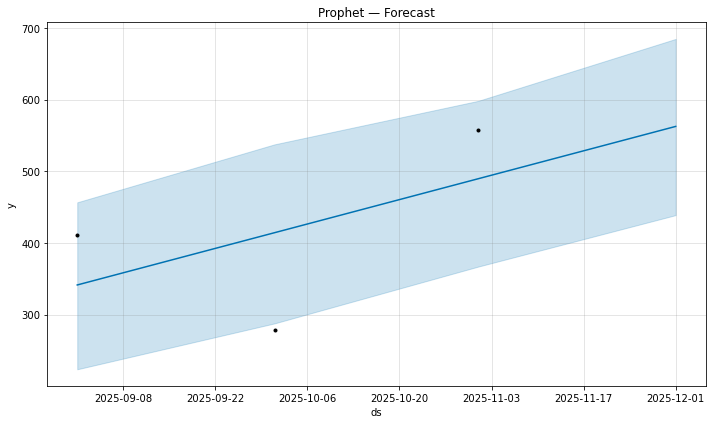

In [11]:
from prophet import Prophet

prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']

train_p = prophet_df.iloc[:split]
test_p  = prophet_df.iloc[split:]

m = Prophet(
    yearly_seasonality=False,  # peu de données
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
m.fit(train_p)

future        = m.make_future_dataframe(periods=len(test_p), freq='MS')
forecast      = m.predict(future)
preds_prophet = forecast['yhat'].iloc[split:].values
mae_prophet   = mean_absolute_error(test_p['y'].values, preds_prophet)
rmse_prophet  = mean_squared_error(test_p['y'].values, preds_prophet) ** 0.5

print(f"Prophet — MAE: {mae_prophet:.2f} | RMSE: {rmse_prophet:.2f}")
m.plot(forecast); plt.title('Prophet — Forecast'); plt.tight_layout(); plt.show()

In [10]:
os.makedirs('../models', exist_ok=True)
joblib.dump(arima_fit, '../models/arima_matches.pkl')
joblib.dump(m,         '../models/prophet_matches.pkl')

forecast_full = m.predict(m.make_future_dataframe(periods=12, freq='MS'))
forecast_full.to_csv('../data/matches_forecast.csv', index=False)

print("✅ Time Series sauvegardée !")
print(f"\nRécap métriques:")
print(f"  ARIMA   — MAE: {mae_arima:.2f}  | RMSE: {rmse_arima:.2f}")
print(f"  Prophet — MAE: {mae_prophet:.2f} | RMSE: {rmse_prophet:.2f}")

✅ Time Series sauvegardée !

Récap métriques:
  ARIMA   — MAE: 360.14  | RMSE: 360.14
  Prophet — MAE: 548.68 | RMSE: 548.68


In [8]:
import sys
!{sys.executable} -m pip install prophet